# Introduction

In the previous notebooks, we studied multivariate Gaussian distributions and used them to formulate Bayesian linear regression through Gaussian conditioning. Gaussian processes extend these ideas from distributions over finite-dimensional parameter vectors to distributions over functions.

In this notebook, we introduce Gaussian processes, their connection to Bayesian linear regression, and their implementation using mean functions and covariance kernels. We also explore several common kernels, their hyperparameters, composition, and prior sampling.

# Imports and Setup

In [1]:
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

warnings.filterwarnings('ignore')
sys.path.append(str(PROJECT_ROOT))

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import random
from matplotlib.axes import Axes

from src.gaussian import Gaussian, GaussianProcess

# From Gaussian Vectors to Gaussian Processes

## Definition

A Gaussian Process (GP) is a collection of random variables defined on an input space $\mathcal{X}$. A random function $f$ is called a Gaussian Process if for any finite set of inputs 
$$x_1, x_2, \dots x_n \in \mathcal{X},$$
the function values 
$$ \begin{bmatrix} f(x_1) \\ f(x_2) \\ \vdots \\ f(x_n) \end{bmatrix} $$
are a multivariate Gaussian distribution.

A Gaussian Process $f \sim \mathcal{GP}(m, k)$ is defined using two entities:
* **mean function:** $$m(x) = \mathbb{E}[f(x)]$$
* **covariance kernel:** $$k(x, x') = \text{Cov}(f(x), f(x'))$$

The mean function determines the expected value of the process at each input. The kernel determines both the marginal variability of the function and the dependence between its values at different inputs. So, basically, a Gaussian Process is a random function defined on some arbitrary input space $\mathcal{X}$. Although it is defined on an entire infinite space, we do not need to (and, actually cant) compute the values on the entire input space. We work on finite samples on that input space.

## Finite-Dimensional Distributions

Let
$$ f \sim \mathcal{GP}(m, k) $$
be a Gaussian Process and 
$$ X = (x_1, x_2, \dots, x_n) \in \mathbb{X}^n $$
be inputs from an input space.

Then, the mean vector is defined as:
$$ m_X = \begin{bmatrix} m(x_1) \\ m(x_2) \\ \vdots \\ m(x_n) \end{bmatrix} $$
and the covariance matrix is defined as:
$$ K_{XX} = \begin{bmatrix} k(x_1, x_1) & k(x_1, x_2) & \dots & k(x_1, x_n) \\
k(x_2, x_1) & k(x_2, x_2) & \dots & k(x_2, x_n) \\
\vdots & \vdots & \ddots & \vdots \\
k(x_n, x_1) & k(x_n, x_2) & \dots & k(x_n, x_n) \end{bmatrix} $$

Thus, for some arbitrary set of inputs, a Gaussian Process produces a multivariate Gaussian distribution:
$$ f: X \mapsto \texttt{Gaussian}\left(m_X, K_{XX}\right) $$

This allows us to use functions defined on Gaussian such as sampling and conditioning on Gaussian Processes as well.

To form a valid Gaussian, a covariance matrix should be symmetric and positive semi-definite. So, a very important condition to form a Gaussian Process is to have positive semi-definite $K_{XX}$ for any set of inputs $X$.

## Relation to Bayesian Regression

The defined above Gaussian Process is tightly connected to the Bayesian regression discussed in the previous notebook. Suppose we have a regression of the form
$$ f_w(x) = \phi(x)^T w, \quad w \sim \mathcal{N}(\mu, \Sigma) $$

Note that $\phi(x)$ is deterministic and randomness is coming from $w$. Then, each sampled weight vector gives us a different function:
$$ w^{(s)} \rightarrow f^{(s)}(x) = \phi(x)^T w^{(s)}  $$

A Gaussian Process' mean function might be considered as the expected value of that function $f$ with respect to the weight vector $w$:
$$ m(x) = \mathbb{E}_w [f_w(x)] $$
and the covariance kernel as the covariance:
$$ k(x, x') = \text{Cov}_w(f_w(x), f_w(x')) $$

For Bayesian linear regression, we can compute those exactly:
$$ m(x) = \phi(x)^T \mu $$
$$ k(x, x') = \phi(x)^T \ \Sigma \ \phi(x') $$

But the cool thing about Gaussian Processes is that we can use different mean functions and covariance kernels, extending the idea further (even for infinite-dimensional feature maps, implying infinite degrees of freedom).

# Mean Function

There are no mathematical constraints on the mean function design, so one can use any of them depending on their needs. Let us consider some of the most common ones. We will consider different covariance kernels in the next section, so let us use RBF kernel as an example for this section:
$$ k(x, x') = \theta^2 \exp \left( -\frac{\|x - x'\|^2}{2 \ell^2} \right) = \theta^2 \exp \left( -\frac{1}{2} \sum_{j=1}^{d} \left( \frac{x_j - x'_j}{\ell} \right)^2 \right) $$
with $\theta = \ell = 1$.

In [3]:
def rbf_kernel(a, b, theta, ell):
    return theta**2 * jnp.exp(- 1/2 * jnp.sum(((a - b) / ell)**2, axis = -1))

def plot_prior(
    prior: Gaussian,
    x: jnp.ndarray,
    n_samples: int | None = None,
    key: jax.Array | None = None,
    title: str | None = None,
    ax: Axes | None = None,
):
    if ax is None:
        ax = plt.gca()

    mean = prior.mu.squeeze()
    std = jnp.sqrt(jnp.diag(prior.Sigma)).squeeze()

    ax.plot(
        x,
        mean,
        label=r"$\mu$",
    )

    ax.fill_between(
        x,
        mean - std,
        mean + std,
        alpha=0.5,
        color="orange",
        label=r"$\mu \pm \sigma$",
    )

    ax.fill_between(
        x,
        mean - 2 * std,
        mean + 2 * std,
        alpha=0.3,
        color="orange",
        label=r"$\mu \pm 2\sigma$",
    )

    if title is not None:
        ax.set_title(title)

    if n_samples is not None:
        samples = prior.sample(sample_size = n_samples, key = key)

        for i, sample in enumerate(samples):
            ax.plot(x, sample, color = "green", alpha = 0.7, label = "samples" if i == 0 else None)

    ax.legend()

    return ax

## Zero Mean

The easiest option is to use zero as the mean function:
$$ m(x) = 0 $$

In [4]:
def zero_mean(x):
    return jnp.zeros(x.shape[:-1])

zero_mean_gp = GaussianProcess(zero_mean, lambda a, b: rbf_kernel(a, b, theta = 1, ell = 1))

In [5]:
x_arr = jnp.arange(0, 5, 0.1).reshape(-1, 1)
prior = zero_mean_gp(x_arr)

<Axes: title={'center': 'Zero Mean'}>

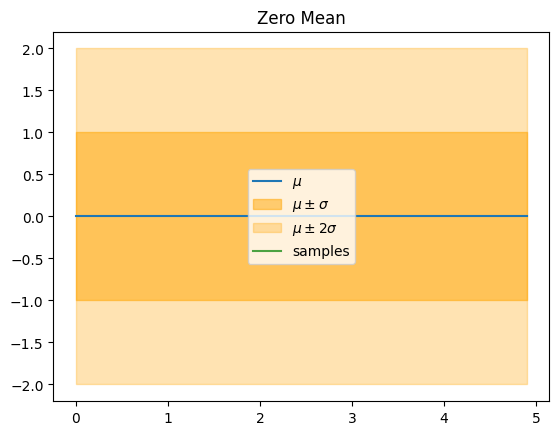

In [6]:
samples_key = random.key(47)

plot_prior(prior, x_arr.flatten(), title = "Zero Mean", n_samples=5, key = samples_key)

So, the mean is zero, not surprising :)

## Constant Mean

Another common mean function choice is constant mean
$$ m(x) = C $$

In [7]:
def constant_mean(x, const):
    return const * jnp.ones(x.shape[:-1])

constant_mean_gp = GaussianProcess(lambda x: constant_mean(x, 5), lambda a, b: rbf_kernel(a, b, theta = 1, ell = 1))

In [8]:
x_arr = jnp.arange(0, 5, 0.1).reshape(-1, 1)
prior = constant_mean_gp(x_arr)

<Axes: title={'center': 'Constant Mean ($C = 5$)'}>

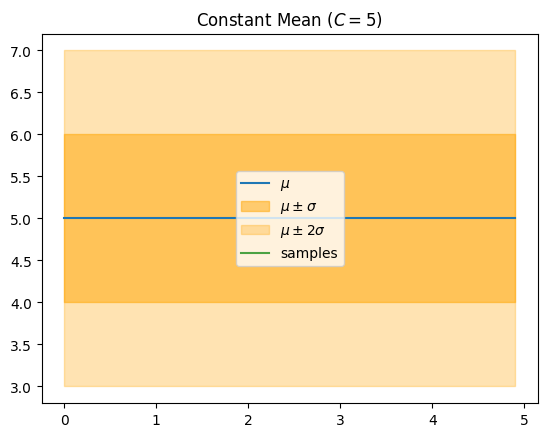

In [9]:
plot_prior(prior, x_arr.squeeze(), title = r"Constant Mean ($C = 5$)", n_samples=5, key = samples_key)

## Linear Mean

One can also use linear function as a mean:
$$ m(x) = kx + l $$

In [10]:
def linear_mean(x, slope, intercept):
    return intercept * jnp.ones(x.shape[:-1]) + slope * x[..., 0]

linear_mean_gp = GaussianProcess(lambda x: linear_mean(x, 4, 7), lambda a, b: rbf_kernel(a, b, theta = 1, ell = 1))

In [11]:
x_arr = jnp.arange(0, 5, 0.1).reshape(-1, 1)
prior = linear_mean_gp(x_arr)

<Axes: title={'center': 'Linear Mean ($4x + 7$)'}>

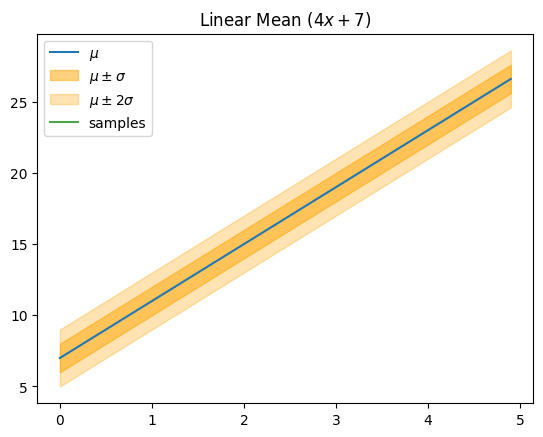

In [12]:
plot_prior(prior, x_arr.squeeze(), title = r"Linear Mean ($4x + 7$)", n_samples=5, key = samples_key)

# Covariance Kernels

In the previous section we have considered different mean functions under RBF kernel. Now let us see how a prior will behave under different covariance kernels. But first, an important mathematical note should be made.

## Valid Kernels

Covariance kernel builds a covariance matrix:
$$ K_{ij} = k(x_i, x_j) = \text{Cov}(f(x_i), f(x_j)) $$

For a covariance matrix to be valid, the matrix must be symmetric and positive semi-definite. So, the following should be true for the function $k$:

* $k(x, x') = k(x', x)$
* $a^T K a \geq 0 \Rightarrow \sum_{i=1}^{n} \sum_{j=1}^{n} a_i a_j k(x_i, x_j), \geq 0 \quad \forall a \in \mathbb{R}^n$

## Radial Basis Function Kernel

Let us first see how different settings of $\theta$ and $\ell$ affect the prior distribution's variance.

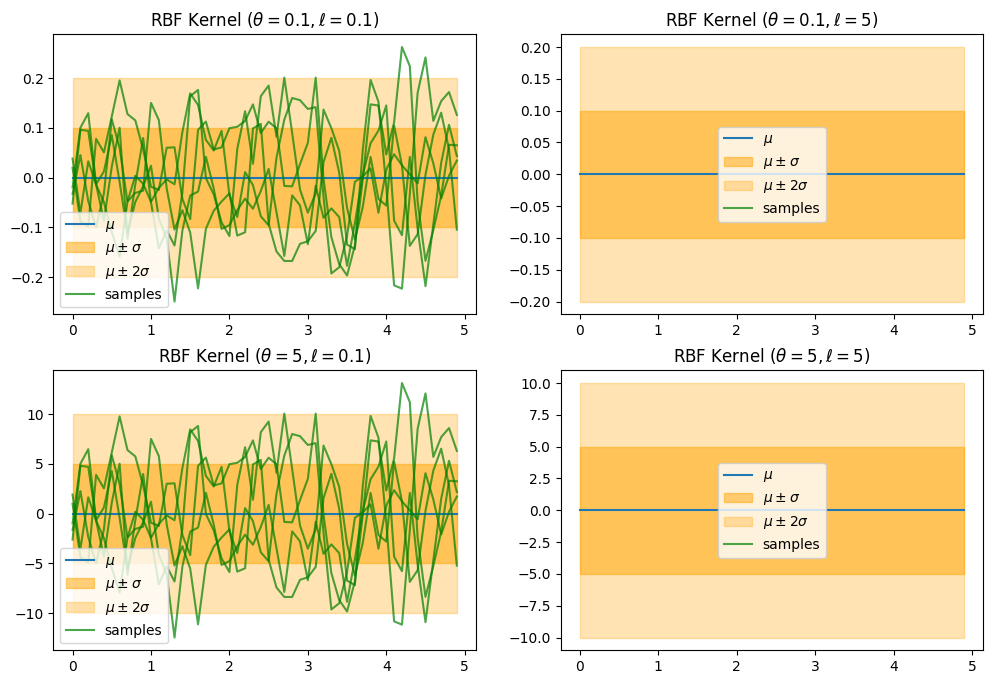

In [13]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (12, 8))

for i, theta in enumerate([0.1, 5]):
    for j, ell in enumerate([0.1, 5]):
        rbf_gp = GaussianProcess(
            zero_mean,
            lambda a, b, theta = theta, ell = ell: rbf_kernel(a, b, theta = theta, ell = ell),
        )
        prior = rbf_gp(x_arr)

        plot_prior(prior, x_arr.squeeze(), title = rf"RBF Kernel ($\theta = {theta}, \ell = {ell}$)", ax = axes[i, j], n_samples = 5, key = samples_key)

As can be seen, the value of $\ell$ affects neither the mean nor the marginal variance of prior distributions at any of the points. It can be explained using the fact that we are only considering the diagonal entries of the prior's covariance matrix. For diagonal entries, $x = x'$, so the exponential part is always equal to 1, thus, only $\theta$ affects the uncertainty bands, while $\ell$ affects the sampled functions.

The value of $\ell$ scales the distance between $x$ and $x'$:

* **large** $\ell$ makes distant points more correlated
* **small** $\ell$ decreases the covariance rapidly, so nearby points are more strongly correlated

The effect of $\ell$ is seen on the samples(smaller $\ell$ results in a more chaotic behaviour) and can also be seen after the observation of some data with the similar idea:

* **large** $\ell$: each observation affects broad region around itself
* **small** $\ell$: each observation affects narrow region around itself

## Linear Kernel

One of the simplest kernels is linear kernel:
$$ k(x, x') = m x^T x' + l, \quad m, l \geq 0 $$

<Axes: title={'center': 'Linear Kernel ($m = 0.5, l = 2$)'}>

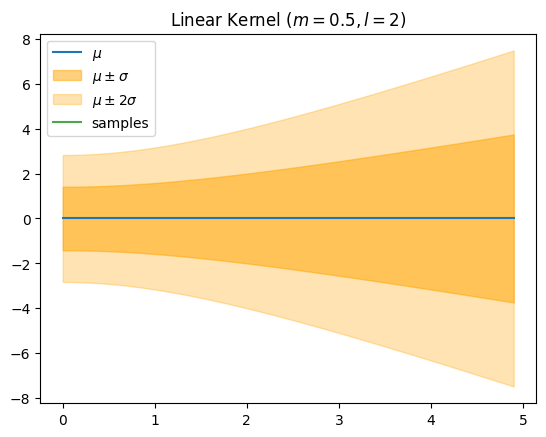

In [14]:
def linear_kernel(a, b, slope, intercept):
    return slope * jnp.sum(a * b, axis=-1) + intercept

linear_kernel_gp = GaussianProcess(zero_mean, lambda a, b: linear_kernel(a, b, slope = 0.5, intercept = 2))
prior = linear_kernel_gp(x_arr)
plot_prior(prior, x_arr.squeeze(), title = r"Linear Kernel ($m = 0.5, l = 2$)", n_samples = 5, key = samples_key)

Here:

* $m$ controls the variance of the slope. Larger $m$ allows more strongly increasing or decreasing sampled lines.
* $l$ controls the variance of the intercept. Larger $l$ allows larger vertical shifts of the sampled lines.

## Matern Kernel

Another widely used kernel is Matern Kernel:
$$ k(x, x') = \theta^2 \frac{2^{1 - \nu}}{\Gamma(\nu)} \left( \frac{\sqrt{2 \nu} \| x - x' \|}{\ell} \right)^{\nu} K_{\nu} \left( \frac{\sqrt{2 \nu} \| x - x' \|}{\ell} \right) $$

Where $K_{\nu}$ is modified Bessel function of order $\nu$. In this notebook, we will use $\nu = 3/2$, thus, the kernel is simplified into:
$$ k(x, x') = \theta^2 \left( 1 + \frac{\sqrt{3} \| x - x' \|}{\ell} \right) \exp \left( -\frac{\sqrt{3} \| x - x' \|}{\ell} \right) $$

<Axes: title={'center': 'Matern Kernel ($\\theta = 1, \\ell = 1$)'}>

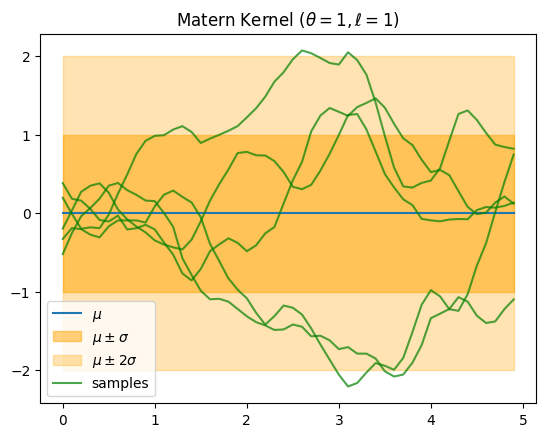

In [15]:
def matern_kernel(a, b, theta, ell):
    norm = jnp.linalg.norm(a-b, 2, axis = -1)
    return theta**2 * (1 + jnp.sqrt(3) * norm / ell) * jnp.exp(-jnp.sqrt(3) * norm / ell)

matern_kernel_gp = GaussianProcess(zero_mean, lambda a, b: matern_kernel(a, b, theta = 1, ell = 1))
prior = matern_kernel_gp(x_arr)
plot_prior(prior, x_arr.squeeze(), title = r"Matern Kernel ($\theta = 1, \ell = 1$)", n_samples = 5, key = samples_key)

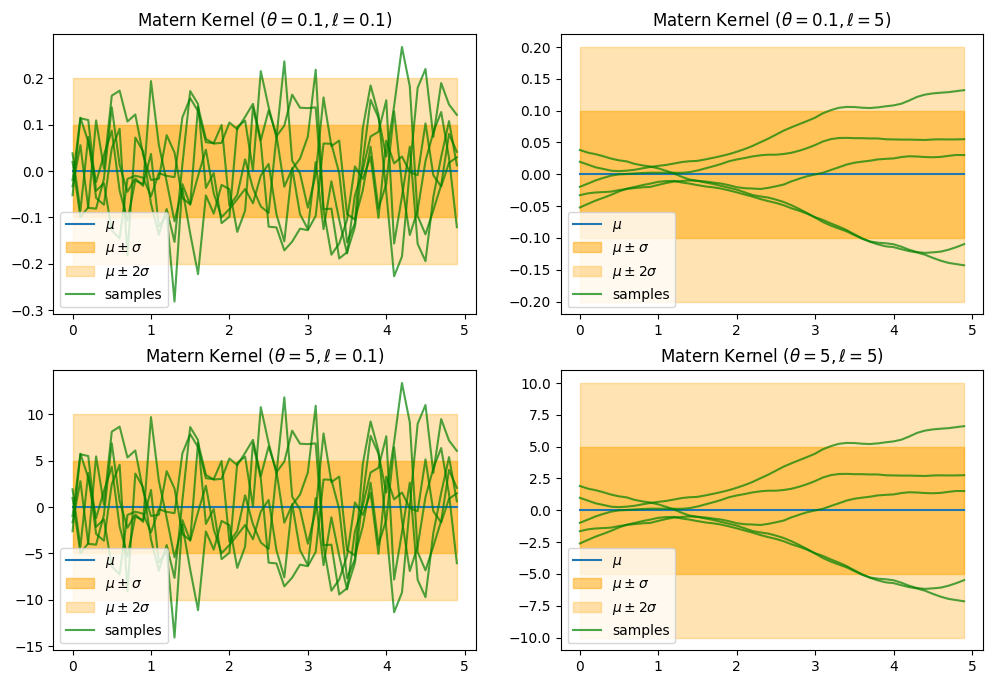

In [16]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (12, 8))

for i, theta in enumerate([0.1, 5]):
    for j, ell in enumerate([0.1, 5]):
        matern_kernel_gp = GaussianProcess(
            zero_mean, 
            lambda a, b, theta = theta, ell = ell: matern_kernel(a, b, theta = theta, ell = ell)
        )
        prior = matern_kernel_gp(x_arr)

        plot_prior(prior, x_arr.squeeze(), title = rf"Matern Kernel ($\theta = {theta}, \ell = {ell}$)", n_samples = 5, key = samples_key, ax = axes[i, j])

The functions of $\theta$ and $\ell$ here are similar to their functions in RBF kernel.

## Rational Quadratic Kernel

It is also common to use Rational Quadratic (RQ) Kernel:
$$ k(x, x') = \theta^2 \left( 1 + \frac{\| x - x' \|^2}{2 \alpha \ell^2} \right)^{-\alpha} $$

<Axes: title={'center': 'RQ Kernel ($\\theta = 1, \\ell = 1, \\alpha = 1$)'}>

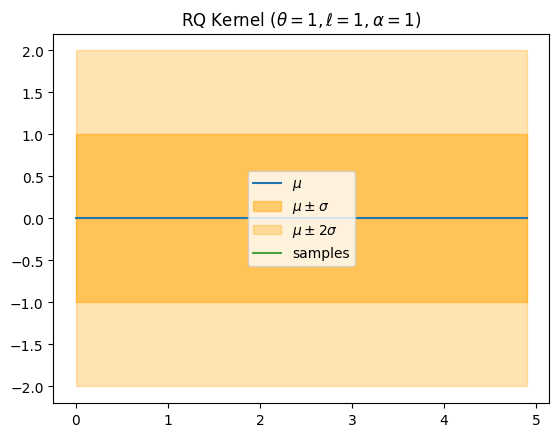

In [17]:
def rq_kernel(a, b, ell, alpha, theta):
    return theta**2 * (1 + jnp.sum(((a - b) / ell)**2, axis = -1) / (2 * alpha))**(-alpha)

rq_kernel_gp = GaussianProcess(zero_mean, lambda a, b: rq_kernel(a, b, theta = 1, alpha = 1, ell = 1))
prior = rq_kernel_gp(x_arr)
plot_prior(prior, x_arr.squeeze(), title = r"RQ Kernel ($\theta = 1, \ell = 1, \alpha = 1$)", n_samples = 5, key = samples_key)

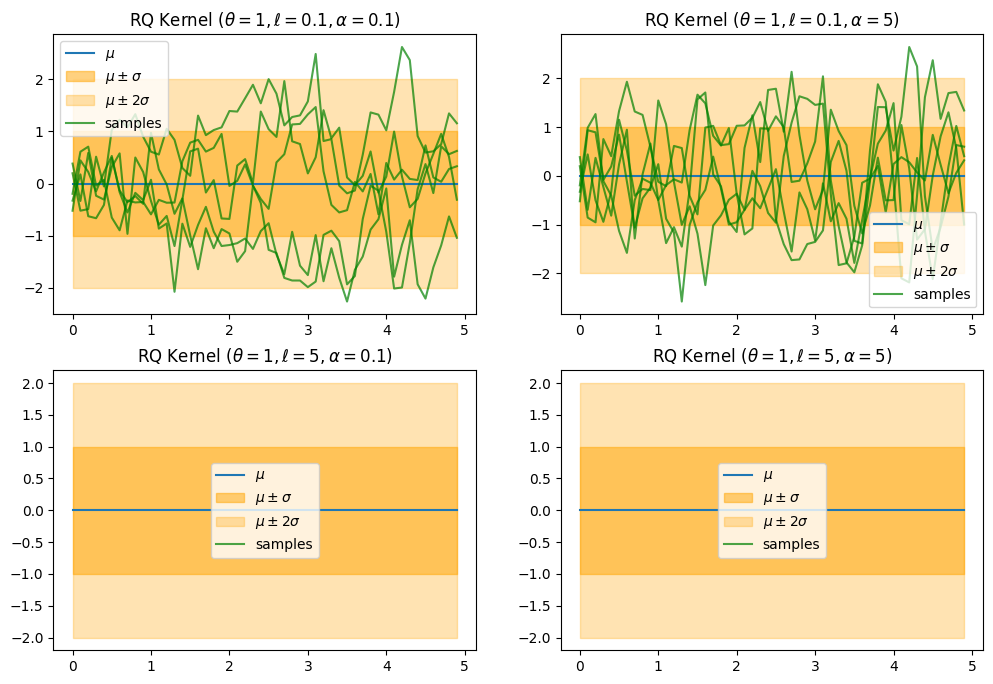

In [18]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (12, 8))

for i, ell in enumerate([0.1, 5]):
    for j, alpha in enumerate([0.1, 5]):
        rq_kernel_gp = GaussianProcess(
            zero_mean, 
            lambda a, b, theta = theta, ell = ell, alpha = alpha: rq_kernel(a, b, theta = 1, ell = ell, alpha = alpha)
        )
        prior = rq_kernel_gp(x_arr)

        plot_prior(prior, x_arr.squeeze(), title = rf"RQ Kernel ($\theta = 1, \ell = {ell}, \alpha = {alpha}$)", n_samples = 5, key = samples_key, ax = axes[i, j])

In RQ kernel, $\alpha$ is the shape or scale-mixture parameter. It controls how broadly different length scales are mixed:

* large $\alpha$: behaves increasingly like an RBF kernel;
* small $\alpha$: allows correlations at several scales and makes covariance decay more slowly with distance.

# Kernel Composition

It is also possible to combine the kernels. Let $k_1$ and $k_2$ be two different valid kernels. Then, we know that both $k_1$ and $k_2$ imply symmetry and positive semi-definiteness. Then, we can combine them using sums and products of kernels, since their composition will also be a valid kernel.

## Sum of Kernels

Let us consider the sum of RBF and Linear kernel under a zero mean function.

<Axes: title={'center': 'RBF + Linear Kernel'}>

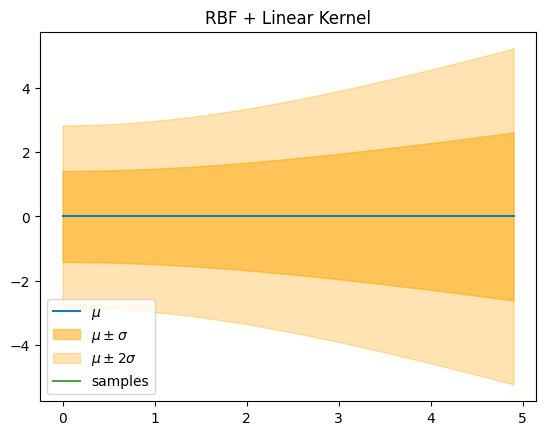

In [19]:
sum_of_kernels_gp = GaussianProcess(zero_mean, 
                                    lambda a, b: rbf_kernel(a, b, theta = 1, ell = 1) + linear_kernel(a, b, slope = 0.2, intercept = 1))
prior = sum_of_kernels_gp(x_arr)
plot_prior(prior, x_arr.squeeze(), title = r"RBF + Linear Kernel", n_samples = 5, key = samples_key)

## Product of Kernels

Now let us see what happens if we multiply the same kernels

<Axes: title={'center': 'RBF $\\times$ Linear Kernel'}>

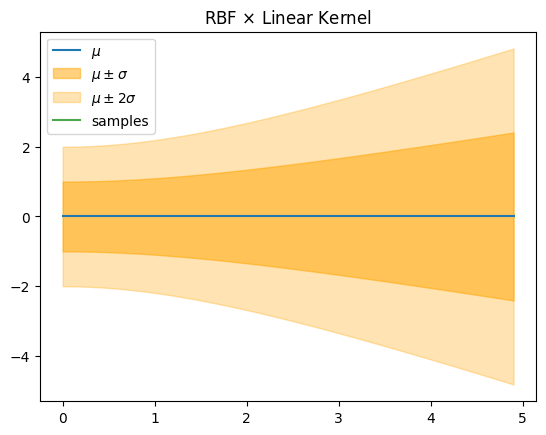

In [20]:
product_of_kernels_gp = GaussianProcess(zero_mean, 
                                        lambda a, b: rbf_kernel(a, b, theta = 1, ell = 1) * linear_kernel(a, b, slope = 0.2, intercept = 1))
prior = product_of_kernels_gp(x_arr)
plot_prior(prior, x_arr.squeeze(), title = r"RBF $\times$ Linear Kernel", n_samples = 5, key = samples_key)

## Intuition Behind the Composition

A sum of kernels,
$$k(x,x') = k_1(x,x') + k_2(x,x')$$
corresponds to adding independent GP components, $f(x)=f_1(x)+f_2(x)$. A product,
$$k(x,x') = k_1(x,x')k_2(x,x')$$
means that two inputs are strongly correlated only when both kernels consider them similar. It represents an interaction between structures, not generally the product $f_1(x)f_2(x)$. Thus, sums of products describe additive collections of interacting patterns.

# Conclusion

Gaussian Processes extend multivariate Gaussian distributions to distributions over functions. Their mean function determines the expected behavior, while the covariance kernel controls variability, smoothness, and dependence between function values. Different kernels encode different assumptions, and their sums and products allow more complex structures to be represented. In practice, a GP is evaluated on a finite set of inputs, producing an ordinary multivariate Gaussian distribution that can be sampled and conditioned on observations.